In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import TensorDataset, DataLoader
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

url = "https://raw.githubusercontent.com/tirtho2002/220150_ANN/main/diabetes.csv"
df = pd.read_csv(url)

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [78]:
df.isnull().sum()


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [79]:
X=df.drop("Outcome", axis=1)
Y=df["Outcome"]

In [80]:

cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

X[cols] = X[cols].replace(0, np.nan)

X[cols] = X[cols].fillna(X[cols].median())

In [81]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [82]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [83]:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

In [84]:

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_val = torch.tensor(y_val.values, dtype=torch.float32).view(-1,1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [85]:

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [86]:
X = df.drop("Outcome", axis=1)
Y = df["Outcome"]

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

In [88]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [89]:
model = Sequential()

model.add(Dense(12, input_dim=8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [90]:

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [91]:
history = model.fit(
    X_train,
    Y_train,
    epochs=100,
    batch_size=10,
    validation_split=0.2
)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4684 - loss: 0.7844 - val_accuracy: 0.5447 - val_loss: 0.6992
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5703 - loss: 0.7016 - val_accuracy: 0.6016 - val_loss: 0.6488
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6334 - loss: 0.6465 - val_accuracy: 0.6667 - val_loss: 0.6114
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6660 - loss: 0.6061 - val_accuracy: 0.6829 - val_loss: 0.5833
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6925 - loss: 0.5751 - val_accuracy: 0.7154 - val_loss: 0.5610
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7189 - loss: 0.5520 - val_accuracy: 0.7236 - val_loss: 0.5444
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7373 - loss: 0.5326 - val_accuracy: 0.7317 - val_loss: 0.5304
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7658 - loss: 0.5187 - val_accuracy: 0.7317 - 

In [92]:
loss, accuracy = model.evaluate(X_test, Y_test)

print("Accuracy:", accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7468 - loss: 0.5767
Accuracy: 0.7467532753944397


In [93]:
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


In [94]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(Y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(Y_test, y_pred))

Confusion Matrix:
[[81 18]
 [21 34]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.82      0.81        99
           1       0.65      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.75      0.75       154



In [95]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(Y_test, y_pred)
precision = precision_score(Y_test, y_pred)
recall = recall_score(Y_test, y_pred)
f1 = f1_score(Y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.7467532467532467
Precision: 0.6538461538461539
Recall   : 0.6181818181818182
F1 Score : 0.6355140186915887


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
AUC Score: 0.7831037649219468


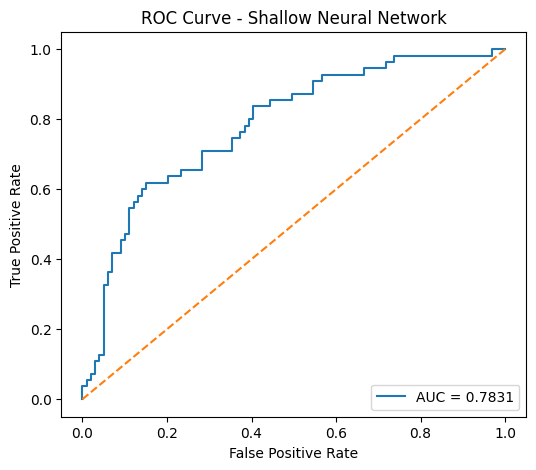

In [97]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities
y_pred_prob = model.predict(X_test).ravel()

# Calculate ROC Curve
fpr, tpr, thresholds = roc_curve(Y_test, y_pred_prob)

# Calculate AUC Score
auc_score = roc_auc_score(Y_test, y_pred_prob)

print("AUC Score:", auc_score)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Shallow Neural Network")
plt.legend(loc="lower right")
plt.show()

In [98]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Deep Neural Network
deep_model = Sequential()

# Input + Hidden Layer 1
deep_model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
deep_model.add(Dropout(0.3))

# Hidden Layer 2
deep_model.add(Dense(32, activation='relu'))
deep_model.add(Dropout(0.3))

# Hidden Layer 3
deep_model.add(Dense(16, activation='relu'))

# Output Layer
deep_model.add(Dense(1, activation='sigmoid'))

# Compile Model
deep_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Model Summary
deep_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [99]:
history_deep = deep_model.fit(
    X_train,
    Y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5845 - loss: 0.6735 - val_accuracy: 0.6423 - val_loss: 0.6630
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6843 - loss: 0.6236 - val_accuracy: 0.6585 - val_loss: 0.6127
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7413 - loss: 0.5750 - val_accuracy: 0.7236 - val_loss: 0.5675
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7291 - loss: 0.5442 - val_accuracy: 0.7236 - val_loss: 0.5382
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7536 - loss: 0.5242 - val_accuracy: 0.7317 - val_loss: 0.5261
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7536 - loss: 0.5073 - val_accuracy: 0.7317 - val_loss: 0.5062
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7454 - loss: 0.5011 - val_accuracy: 0.7317 - val_loss: 0.4961
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7597 - loss: 0.5030 - val_accuracy: 0.7561

In [101]:
loss, accuracy = deep_model.evaluate(X_test, Y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7273 - loss: 0.6461
Test Loss: 0.6461384892463684
Test Accuracy: 0.7272727489471436


In [104]:

print("=" * 60)
print("Shallow Neural Network Architecture")
print("=" * 60)
print(model)

print("\n")

print("=" * 60)
print("Deep Neural Network Architecture")
print("=" * 60)
print(deep_model)

Shallow Neural Network Architecture
<Sequential name=sequential_1, built=True>


Deep Neural Network Architecture
<Sequential name=sequential_2, built=True>
